<style>
    /* Redéfinit TOUS les Titres 1 (#) du notebook */
    h1 {
        color: #008080 !important;          /* Couleur bleu canard */
        font-weight: bold !important;
        border-bottom: 2px solid #008080;   /* Une jolie ligne en dessous */
        padding-bottom: 5px;
    }
    
    /* Redéfinit TOUS les Titres 2 (##) du notebook */
    h2 {
        color: #4682B4 !important;          /* Couleur bleu acier */
        font-style: italic !important;
    }
</style>

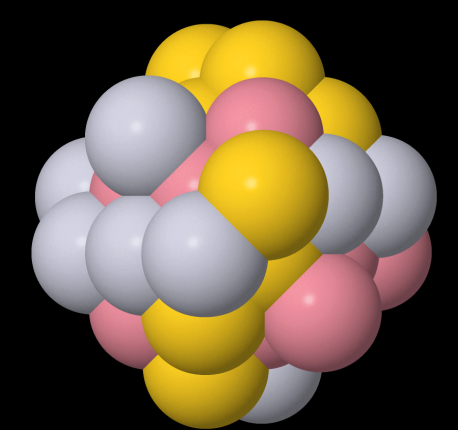
Nanoparticule Au

In [ ]:
import HBPy.Molecule.Tools
from pathlib import Path
import numpy
from collections import defaultdict
import matplotlib.pyplot as plt

# Lecture des fichier xmu.dat pour tous les atomes composant la nanoparticule

In [50]:
dossier = Path("/home/bulou/src/ATOMOD/simul_save/feff_input_files/")
# Parcourir tout le contenu
series = defaultdict(list)
list_elt=[]
for element in dossier.iterdir():
    #print(element.name)
    data=Path(f"{dossier}/{element.name}/xmu.dat")
    if data.exists():
        energy, chi = numpy.loadtxt(data, comments='#', usecols=(2, 5), unpack=True)
        clef=element.name.split("_")[0]
        if clef in series:
            series[clef].append((energy,chi))
        else:
            series[clef]=[(energy,chi)]
            list_elt.append(clef)
print(list_elt)

['Co', 'Au', 'Pt']


# Sommation des signaux EXFAS par 

In [51]:
for elt in list_elt:
    k,chi,dev=HBPy.Molecule.Tools.mk_mean(series[elt])
    series[elt].append((k,chi))


2026-06-09 10:32:41,971 - INFO - Plage commune: [0.05, 20.00]
2026-06-09 10:32:41,977 - INFO - Plage commune: [0.05, 20.00]
2026-06-09 10:32:41,982 - INFO - Plage commune: [0.05, 20.00]


# Affichage des résultats

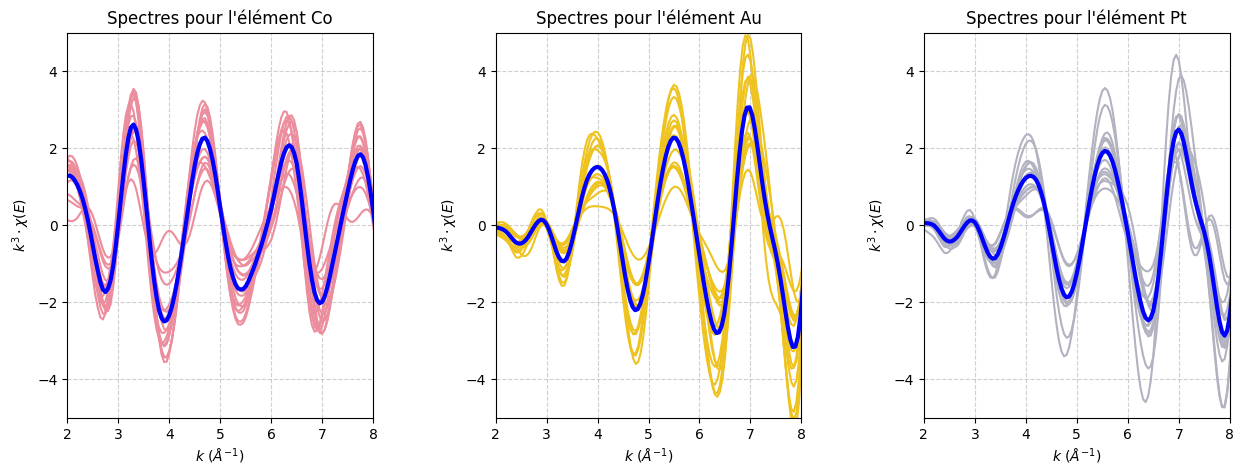

In [59]:
# 1. On calcule la largeur idéale de l'image (par exemple 5 pouces par graphique)
largeur = 5 * len(list_elt)
# 2. L'astuce : on donne [list_elt] à subplot_mosaic !
# Si list_elt = ['Fe', 'Ni'], cela crée la grille [['Fe', 'Ni']]
fig, ax = plt.subplot_mosaic([list_elt], figsize=(largeur, 5))
color={}
color['Co']=(236/255,141/255,157/255)
color['Au']=(238/255,195/255,32/255)
color['Pt']=(178/255,178/255,193/255)

idx=3

if idx==0:
    by=0.15
    ylbl=r"$\chi(E)$"
    savename="chi(k)"
    header="# k (A^-1)   chi(k)"
elif idx==1:
    by=0.30
    ylbl=r"$k\cdot\chi(E)$"
    savename="kchi(k)"
    header="# k (A^-1)   k.chi(k)"
elif idx==2:
    by=1.0
    ylbl=r"$k^2\cdot\chi(E)$"
    savename="k2chi(k)"
    header="# k (A^-1)   k^2.chi(k)"
elif idx==3:
    by=5.0
    ylbl=r"$k^3\cdot\chi(E)$"
    savename="k3chi(k)"
    header="# k (A^-1)   k^3.chi(k)"

for clef in list_elt:
    for i, (k, chi) in enumerate(series[clef][:-1]):
        # L'utilisation de 'enumerate' donne un compteur 'i' (0, 1, 2...) très pratique pour la légende
        ax[clef].plot(k, chi*k**idx, label=f"Configuration {i+1}",color=color[clef])
    k,chiglob=series[clef][-1]
    ax[clef].plot(k,chiglob*k**idx, label=f"Configuration {i+1}",color='blue',linewidth=3)

    # Esthétique du graphique
    ax[clef].set_xlabel(r"$k \ (\AA^{-1})$")
    ax[clef].set_ylabel(ylbl) # Le 'r' permet de lire correctement les caractères spéciaux
    ax[clef].set_title(f"Spectres pour l'élément {clef}")
    #plt.legend()
    ax[clef].grid(True, linestyle='--', alpha=0.6)
    ax[clef].set_xlim(2, 8)
    ax[clef].set_ylim(-by,by)

    numpy.savetxt(
        f"{savename}_{clef}.dat",          # Nom du fichier à créer
        numpy.column_stack((k, chiglob)),           # Les données en colonnes
        delimiter="   ",            # Séparateur (ici 3 espaces, ou '\t' pour une tabulation)
        header=header, # (Optionnel) Première ligne de texte
        comments="# ",              # (Optionnel) Symbole au début de l'entête (comme vos fichiers FEFF)
        fmt="%.6f"                  # (Optionnel) Format des nombres : ici des floats avec 6 décimales
    )
fig.subplots_adjust(wspace=0.4)
plt.savefig(
    f"{savename}.png",  # Nom du fichier (avec l'extension voulue)
    dpi=300,                 # Résolution (300 DPI = qualité impression/publication)
    bbox_inches='tight'      # Ajuste la boîte pour ne JAMAIS couper les labels ou les titres
)

plt.show()

In [42]:
import HBPy

In [43]:
dir(HBPy)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']